In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

In [2]:
#Load data
df=pd.read_csv('../data/featured_data/featured_data.csv')

In [3]:
X=df.drop(columns=['Target'])
y=df['Target']

In [4]:
#Train/Test split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

In [5]:
print(f"Train:{X_train.shape}, Test:{X_test.shape}")
print(f"Target distribution:\n{y_train.value_counts(normalize=True)}")

Train:(1075212, 44), Test:(268803, 44)
Target distribution:
Target
0    0.800398
1    0.199602
Name: proportion, dtype: float64


In [6]:
#Scale features
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

In [ ]:
#  1. LOGISTIC REGRESSION (Baseline Model)

print("Training Logistic Regression...")
lr_model=LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr= lr_model.predict(X_test_scaled)
y_proba_lr=lr_model.predict_proba(X_test_scaled)[:,1]

Training Logistic Regression...


In [8]:
# 2. RANDOM FOREST

print("Training Random Forest...")

rf_model= RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,
                                 class_weight='balanced',n_jobs=-1)

rf_model.fit(X_train_scaled,y_train)

y_pred_rf=rf_model.predict(X_test_scaled)
y_proba_rf=rf_model.predict_proba(X_test_scaled)[:,1]

Training Random Forest...


In [9]:
# 3. XGBOOST 

#Calculate scale_pos_weight for imbalanced data
scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Scale pos weight: {scale_pos_weight:.2f}")

print("Training XGBoost..")
xgb_model=XGBClassifier(n_estimators=100,max_depth=6, learning_rate=0.1,
                        scale_pos_weight=scale_pos_weight,
                        random_state=42,
                        n_jobs=-1,
                        eval_metric='auc')

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb= xgb_model.predict(X_test_scaled)
y_proba_xgb= xgb_model.predict_proba(X_test_scaled)[:,1]

Scale pos weight: 4.01
Training XGBoost..


In [10]:
# EVALUATION FUNCTION

def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{'='*50}")
    print(f"{name} Results")
    print('='*50)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }


In [11]:
# COMPARE ALL MODELS

results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb))

# Create comparison DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))



Logistic Regression Results
Accuracy:  0.6598
Precision: 0.3228
Recall:    0.6419
F1 Score:  0.4296
ROC-AUC:   0.7114

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.76    215149
           1       0.32      0.64      0.43     53654

    accuracy                           0.66    268803
   macro avg       0.60      0.65      0.59    268803
weighted avg       0.77      0.66      0.69    268803


Random Forest Results
Accuracy:  0.6413
Precision: 0.3141
Recall:    0.6733
F1 Score:  0.4283
ROC-AUC:   0.7120

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    215149
           1       0.31      0.67      0.43     53654

    accuracy                           0.64    268803
   macro avg       0.60      0.65      0.58    268803
weighted avg       0.77      0.64      0.68    268803


XGBoost Results
Accuracy:  0.6494
Precision: 0.3213
Recall:    0.

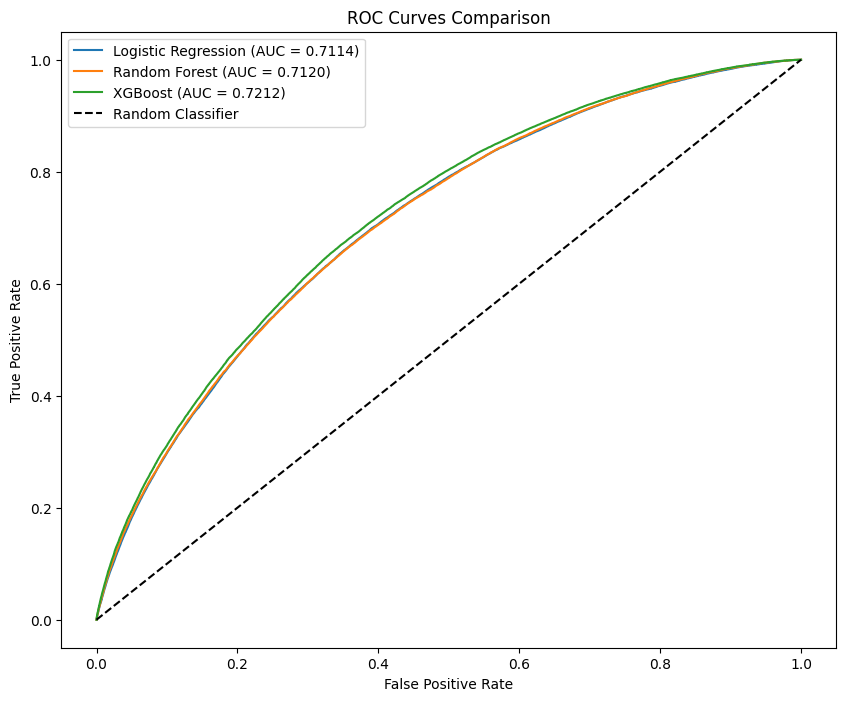

In [12]:
# ============================================
# ROC CURVES
# ============================================
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 8))

for name, y_proba in [("Logistic Regression", y_proba_lr), 
                       ("Random Forest", y_proba_rf), 
                       ("XGBoost", y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison')
ax.legend()
plt.show()


In [13]:
# ============================================
# THRESHOLD ANALYSIS - ALL MODELS
# ============================================
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
models = {
    'Logistic Regression': y_proba_lr,
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb
}

results = []

for model_name, y_proba in models.items():
    for thresh in thresholds:
        y_pred_thresh = (y_proba >= thresh).astype(int)
        results.append({
            'Model': model_name,
            'Threshold': thresh,
            'Precision': precision_score(y_test, y_pred_thresh),
            'Recall': recall_score(y_test, y_pred_thresh),
            'F1': f1_score(y_test, y_pred_thresh)
        })

results_df = pd.DataFrame(results)

# Display pivot table for easy comparison
print("="*70)
print("RECALL COMPARISON (Higher = Catches more defaults)")
print("="*70)
print(results_df.pivot(index='Threshold', columns='Model', values='Recall').round(4))

print("\n" + "="*70)
print("PRECISION COMPARISON (Higher = Fewer false alarms)")
print("="*70)
print(results_df.pivot(index='Threshold', columns='Model', values='Precision').round(4))

print("\n" + "="*70)
print("F1 COMPARISON (Balance of both)")
print("="*70)
print(results_df.pivot(index='Threshold', columns='Model', values='F1').round(4))


RECALL COMPARISON (Higher = Catches more defaults)
Model      Logistic Regression  Random Forest  XGBoost
Threshold                                             
0.3                     0.9376         0.9464   0.9310
0.4                     0.8203         0.8455   0.8356
0.5                     0.6419         0.6733   0.6804
0.6                     0.4353         0.4226   0.4708
0.7                     0.2500         0.1899   0.2530

PRECISION COMPARISON (Higher = Fewer false alarms)
Model      Logistic Regression  Random Forest  XGBoost
Threshold                                             
0.3                     0.2363         0.2328   0.2425
0.4                     0.2743         0.2673   0.2769
0.5                     0.3228         0.3141   0.3213
0.6                     0.3791         0.3846   0.3807
0.7                     0.4455         0.4793   0.4636

F1 COMPARISON (Balance of both)
Model      Logistic Regression  Random Forest  XGBoost
Threshold                              

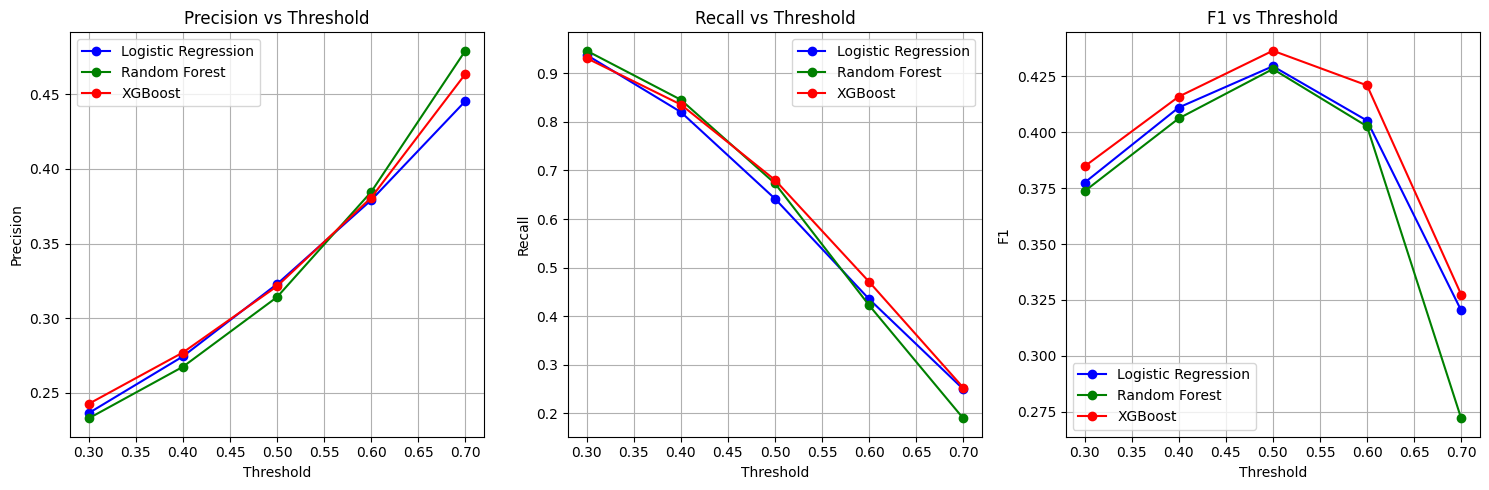

In [14]:
# ============================================
# VISUALIZATION - ALL MODELS THRESHOLD COMPARISON
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Precision', 'Recall', 'F1']
colors = {'Logistic Regression': 'blue', 'Random Forest': 'green', 'XGBoost': 'red'}

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    for model_name in models.keys():
        model_data = results_df[results_df['Model'] == model_name]
        ax.plot(model_data['Threshold'], model_data[metric], 
                marker='o', label=model_name, color=colors[model_name])
    
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Threshold')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [15]:
# ============================================
# FIND BEST MODEL + THRESHOLD COMBINATION
# ============================================
print("\n" + "="*70)
print("TOP 5 MODEL + THRESHOLD COMBINATIONS (by F1 Score)")
print("="*70)
print(results_df.sort_values('F1', ascending=False).head(10).to_string(index=False))

print("\n" + "="*70)
print("TOP 5 MODEL + THRESHOLD COMBINATIONS (by Recall - Conservative)")
print("="*70)
# Filter for recall > 0.8 (catch at least 80% of defaults)
high_recall = results_df[results_df['Recall'] >= 0.8].sort_values('Precision', ascending=False)
print(high_recall.head(5).to_string(index=False))



TOP 5 MODEL + THRESHOLD COMBINATIONS (by F1 Score)
              Model  Threshold  Precision   Recall       F1
            XGBoost        0.5   0.321342 0.680415 0.436525
Logistic Regression        0.5   0.322816 0.641872 0.429583
      Random Forest        0.5   0.314062 0.673277 0.428324
            XGBoost        0.6   0.380741 0.470813 0.421013
            XGBoost        0.4   0.276905 0.835613 0.415967
Logistic Regression        0.4   0.274280 0.820274 0.411099
      Random Forest        0.4   0.267323 0.845510 0.406214
Logistic Regression        0.6   0.379076 0.435308 0.405250
      Random Forest        0.6   0.384595 0.422578 0.402693
            XGBoost        0.3   0.242487 0.931002 0.384760

TOP 5 MODEL + THRESHOLD COMBINATIONS (by Recall - Conservative)
              Model  Threshold  Precision   Recall       F1
            XGBoost        0.4   0.276905 0.835613 0.415967
Logistic Regression        0.4   0.274280 0.820274 0.411099
      Random Forest        0.4   0.267323 0

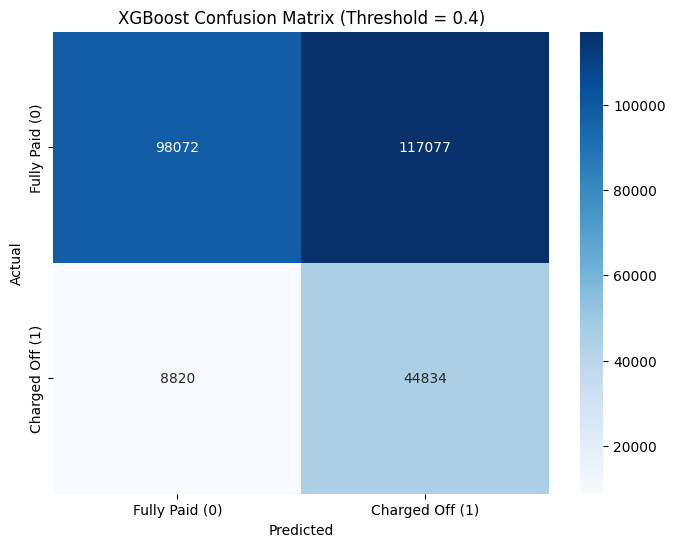


Final Model Performance (Threshold = 0.4):
Precision: 0.2769
Recall:    0.8356
F1 Score:  0.4160


In [16]:
# ============================================
# CONFUSION MATRIX (XGBoost @ Threshold 0.4)
# ============================================
BEST_THRESHOLD = 0.4
y_pred_final = (y_proba_xgb >= BEST_THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'XGBoost Confusion Matrix (Threshold = {BEST_THRESHOLD})')
ax.set_xticklabels(['Fully Paid (0)', 'Charged Off (1)'])
ax.set_yticklabels(['Fully Paid (0)', 'Charged Off (1)'])
plt.show()

print(f"\nFinal Model Performance (Threshold = {BEST_THRESHOLD}):")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_final):.4f}")


In [ ]:
#Saving Models
import pickle
import os

os.makedirs('../models', exist_ok=True)

BEST_THRESHOLD = 0.4

# Save XGBoost model
with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
feature_names = X.columns.tolist()
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Save threshold
with open('../models/threshold.pkl', 'wb') as f:
    pickle.dump(BEST_THRESHOLD, f)

print("="*50)
print("ARTIFACTS SAVED")
print("="*50)
print(f"Model: XGBoost")
print(f"Threshold: {BEST_THRESHOLD}")
print(f"Features: {len(feature_names)}")
print(f"Location: ../models/")


ARTIFACTS SAVED
Model: XGBoost
Threshold: 0.4
Features: 44
Location: ../models/
